In [54]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score

import matplotlib.pyplot as plt

In [55]:
try: 
    df = pd.read_csv('03.BaseDPEvolucaoMensalCisp.csv', encoding='iso-8859-1', sep=';')
    df.info()



except Exception as e:
    print(f'Erro ao obter dados: {e}')

<class 'pandas.DataFrame'>
RangeIndex: 34848 entries, 0 to 34847
Data columns (total 63 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   cisp                        34848 non-null  int64  
 1   mes                         34848 non-null  int64  
 2   ano                         34848 non-null  int64  
 3   mes_ano                     34848 non-null  str    
 4   aisp                        34848 non-null  int64  
 5   risp                        34848 non-null  int64  
 6   munic                       34848 non-null  str    
 7   mcirc                       34848 non-null  int64  
 8   regiao                      34848 non-null  str    
 9   hom_doloso                  34848 non-null  int64  
 10  lesao_corp_morte            34848 non-null  int64  
 11  latrocinio                  34848 non-null  int64  
 12  cvli                        34848 non-null  int64  
 13  hom_por_interv_policial     34848 non-null

In [56]:
coluna1 = 'roubo_transeunte' 
coluna2 = 'roubo_celular'


In [57]:
r = df[coluna1].corr(df[coluna2])
print(f'r de Pearson: {r: .4f}')

r de Pearson:  0.7154


In [58]:
x = df[[coluna1]]
y = df[coluna2]

scaler = MinMaxScaler()
X_scaled = x #scaler.fit_transform(x)



In [59]:
x_treino, x_teste, y_treino, y_teste = (train_test_split(X_scaled, y, test_size=0.2, random_state=42))

In [60]:
model = LinearRegression()
model.fit(x_treino, y_treino)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [61]:
y_pred  = model.predict(x_teste)

r2 = r2_score(y_teste, y_pred)

print(f'r2_score: {r2:.4f}')
print(f'Coeficiente Angular (a): {model.coef_[0]:.4f}')
print(f'Intercepto (b): {model.intercept_:4f}')

r2_score: 0.5136
Coeficiente Angular (a): 0.1892
Intercepto (b): 1.365953


In [62]:
# novo_dado = scaler.transform([[3]])
previsao = model.predict([[200]])
print(f'Para 3 roubos de rua -> roubo de celular previsto: {previsao[0]:.2f}')

Para 3 roubos de rua -> roubo de celular previsto: 39.21


c:\Users\martins.ryan\an-lise\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


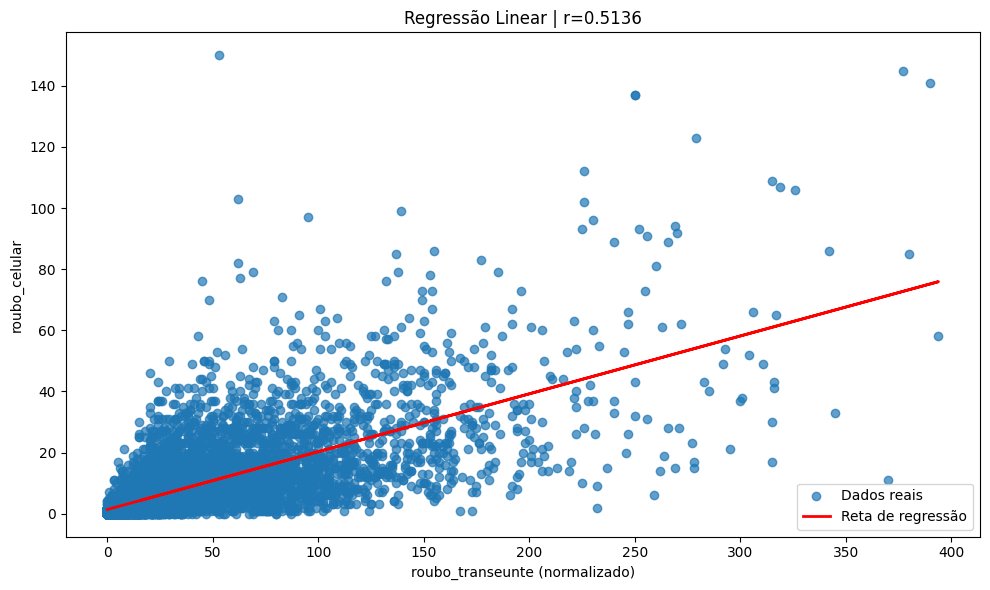

In [63]:
plt.figure(figsize=(10, 6))
plt.scatter(x_teste, y_teste, alpha=0.7, label ='Dados reais')
plt.plot(x_teste, y_pred, linewidth=2, color='red', label='Reta de regressão')
plt.xlabel(f'{coluna1} (normalizado)')
plt.ylabel(f'{coluna2}')
plt.title(f'Regressão Linear | r={r2:.4f}')
plt.legend()
plt.tight_layout()
plt.show()